In [1]:
# ---------------------------------------------------------
# If you are running in a Jupyter or Colab environment,
# install 'fredapi' first by uncommenting the following line:
# !pip install fredapi
# ---------------------------------------------------------

!pip install fredapi

import pandas as pd
import numpy as np
from fredapi import Fred
import os

pd.options.display.max_columns = None

In [2]:
# 1. Your FRED API key
fred_api_key = "a051f637ff06f722b6837a28d9a45e85"
fred = Fred(api_key=fred_api_key)

In [3]:
# 2. Dictionary of ~100 FRED series (some may not be strictly "daily" or fully active)
fred_series_ids = {
    # 1–11: Treasury Constant Maturity Rates (Daily)
    "DGS1MO": "1-Month Treasury Constant Maturity Rate",
    "DGS3MO": "3-Month Treasury Constant Maturity Rate",
    "DGS6MO": "6-Month Treasury Constant Maturity Rate",
    "DGS1": "1-Year Treasury Constant Maturity Rate",
    "DGS2": "2-Year Treasury Constant Maturity Rate",
    "DGS3": "3-Year Treasury Constant Maturity Rate",
    "DGS5": "5-Year Treasury Constant Maturity Rate",
    "DGS7": "7-Year Treasury Constant Maturity Rate",
    "DGS10": "10-Year Treasury Constant Maturity Rate",
    "DGS20": "20-Year Treasury Constant Maturity Rate",
    "DGS30": "30-Year Treasury Constant Maturity Rate",

    # 12–14: T-Bill Secondary Market Rates (Daily)
    "DTB4WK": "4-Week Treasury Bill: Secondary Market Rate",
    "DTB3": "3-Month Treasury Bill: Secondary Market Rate",
    "DTB6": "6-Month Treasury Bill: Secondary Market Rate",

    # 15–19: Corporate Bond Spreads (Daily)
    "BAMLH0A0HYM2": "ICE BofA US High Yield Master II OAS",
    "BAMLCC0A1AA": "ICE BofA AAA US Corporate Index OAS",
    "BAMLCC0A3A": "ICE BofA Single-A US Corporate Index OAS",
    "BAMLCC0A4BBB": "ICE BofA BBB US Corporate Index OAS",
    "BAMLCC0A5BB": "ICE BofA BB US Corporate Index OAS",

    # 20–26: Federal Funds, Bank, and Repo Rates (Daily)
    "EFFR": "Effective Federal Funds Rate",
    "IORR": "Interest Rate on Reserve Balances (IORR)",
    "IOER": "Interest Rate on Excess Reserves (Discontinued)",
    "OBFR": "Overnight Bank Funding Rate",
    "SOFR": "Secured Overnight Financing Rate",
    "TEDRATE": "TED Spread",
    "RRPONTSYD": "Overnight Reverse Repurchase Agreements Award Rate",

    # 27–31: LIBOR (Daily)
    "USD1MTD156N": "1-Month LIBOR (USD)",
    "USD3MTD156N": "3-Month LIBOR (USD)",
    "USD6MTD156N": "6-Month LIBOR (USD)",
    "GBP1MTD156N": "1-Month LIBOR (GBP)",
    "GBP3MTD156N": "3-Month LIBOR (GBP)",

    # 32–45: Exchange Rates (Daily, “DEX” prefix from FRED)
    "DEXUSEU": "U.S. Dollar to Euro Exchange Rate",
    "DEXJPUS": "U.S. Dollar to Japanese Yen Exchange Rate",
    "DEXUSUK": "U.S. Dollar to U.K. Pound Sterling Exchange Rate",
    "DEXCAUS": "Canadian Dollar to U.S. Dollar Exchange Rate",
    "DEXCHUS": "Chinese Yuan to U.S. Dollar Exchange Rate",
    "DEXMXUS": "Mexican Peso to U.S. Dollar Exchange Rate",
    "DEXKOUS": "South Korean Won to U.S. Dollar Exchange Rate",
    "DEXBZUS": "Brazilian Real to U.S. Dollar Exchange Rate",
    "DEXARUS": "Argentine Peso to U.S. Dollar Exchange Rate",
    "DEXINUS": "Indian Rupee to U.S. Dollar Exchange Rate",
    "DEXSZUS": "Swiss Franc to U.S. Dollar Exchange Rate",
    "DEXSIUS": "Singapore Dollar to U.S. Dollar Exchange Rate",
    "DEXHKUS": "Hong Kong Dollar to U.S. Dollar Exchange Rate",
    "DEXTAUS": "New Taiwan Dollar to U.S. Dollar Exchange Rate",

    # 46–49: Additional Exchange Rates
    "DEXTHUS": "Thai Baht to U.S. Dollar Exchange Rate",
    "DEXSDUS": "Swedish Krona to U.S. Dollar Exchange Rate",
    "DEXSLUS": "Sri Lankan Rupee to U.S. Dollar Exchange Rate",
    "DEXNOUS": "Norwegian Krone to U.S. Dollar Exchange Rate",

    # 50–54: Key Commodities (Daily)
    "DCOILWTICO": "Crude Oil Prices: WTI",
    "DCOILBRENTEU": "Crude Oil Prices: Brent - Europe",
    "GOLDAMGBD228NLBM": "Gold Fixing Price 10:30 A.M. (London)",
    "SLVPRUSD": "Silver Price (check if truly daily)",
    "DHHNGSP": "Henry Hub Natural Gas Spot Price",

    # 55: Jet Fuel (Daily)
    "DJFUELUSGULF": "U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price",

    # 56–60: Equity Indexes (Daily)
    "SP500": "S&P 500 Index",
    "VIXCLS": "CBOE Volatility Index (VIX)",
    "NASDAQCOM": "NASDAQ Composite Index",
    "DJIA": "Dow Jones Industrial Average",
    "WILL5000IND": "Wilshire 5000 Total Market Index",

    # 61–65: ICE BofA Corporate Yields (Daily)
    "BAMLC0A1CAAAEY": "ICE BofA AAA US Corp Index Effective Yield",
    "BAMLC0A2CAAEY": "ICE BofA AA US Corp Index Effective Yield",
    "BAMLC0A3CAEY": "ICE BofA Single-A US Corp Index Effective Yield",
    "BAMLC0A4CBBBEY": "ICE BofA BBB US Corp Index Effective Yield",
    "BAMLH0A0HYBBEY": "ICE BofA US High Yield Master II Effective Yield",

    # 66: Bank Prime Loan Rate (Daily updates only when changed)
    "DPRIME": "Bank Prime Loan Rate",

    # 67–71: More LIBOR variants (Daily)
    "GBP6MTD156N": "6-Month LIBOR (GBP)",
    "CHF3MTD156N": "3-Month LIBOR (CHF)",
    "JPN3MTD156N": "3-Month LIBOR (JPY)",
    "EUR3MTD156N": "3-Month LIBOR (EUR)",
    "USDONTD156N": "Overnight LIBOR (USD)",

    # 72–76: Additional “DEX” exchange rates
    "DEXDNUS": "Danish Krone to U.S. Dollar Exchange Rate",
    "DEXALUS": "Albanian Lek to U.S. Dollar Exchange Rate",
    "DEXCZHUS": "Czech Koruna to U.S. Dollar Exchange Rate",
    "DEXMAUS": "Moroccan Dirham to U.S. Dollar Exchange Rate",
    "DEXPLUS": "Polish Zloty to U.S. Dollar Exchange Rate",

    # 77–79: More daily rates/spreads
    "BAMLH0A1CAAEY": "ICE BofA CCC & Lower US High Yield Index Effective Yield",
    "T10YIE": "10-Year Breakeven Inflation Rate",
    "T5YIE": "5-Year Breakeven Inflation Rate",

    # 80–82: Treasury Inflation-Indexed Security (TIPS) Yields (Daily)
    "DFII5": "5-Year TIPS Yield",
    "DFII10": "10-Year TIPS Yield",
    "DFII30": "30-Year TIPS Yield",

    # 83–92: ICE Swap Rates (Daily, if available)
    "ICERATES1100USD1Y": "1-Year ICE Swap Rate (USD)",
    "ICERATES1100USD2Y": "2-Year ICE Swap Rate (USD)",
    "ICERATES1100USD3Y": "3-Year ICE Swap Rate (USD)",
    "ICERATES1100USD5Y": "5-Year ICE Swap Rate (USD)",
    "ICERATES1100USD7Y": "7-Year ICE Swap Rate (USD)",
    "ICERATES1100USD10Y": "10-Year ICE Swap Rate (USD)",
    "ICERATES1100USD30Y": "30-Year ICE Swap Rate (USD)",
    "BAMLH0A3HYCEY": "ICE BofA Single-B US High Yield Index Effective Yield",
    "T20YIEM": "20-Year Breakeven Inflation Rate (check freq)",
    "DHOILNYH": "No. 2 Heating Oil, New York Harbor (check daily)",

    # 93–100: Fillers (some not daily!)
    "DGASSP": "Gasoline Spot Price (US Average, check freq)",
    "MICH": "U of Michigan: Consumer Sentiment (likely monthly)",
    "ICSA": "Initial Jobless Claims (weekly)",
    "WALCL": "Fed Assets (weekly)",
    "CPIAUCSL": "CPI for All Urban Consumers (monthly)",
    "GS10": "10-Year Treasury (alias for DGS10?)",
    "T7YIE": "7-Year Breakeven Inflation Rate (check freq)",
    "PNAPETHUSDM": "Palladium Price (check freq)"
}

In [4]:
# 2. Dictionary of ~100 FRED series (some may not be strictly "daily" or fully active)
fred_series = {
    # 1–11: Treasury Constant Maturity Rates (Daily)
    "DGS1MO": "1-Month Treasury Constant Maturity Rate",
    "DGS6MO": "6-Month Treasury Constant Maturity Rate",
    "DGS1": "1-Year Treasury Constant Maturity Rate",
    "DGS5": "5-Year Treasury Constant Maturity Rate",
    "DGS10": "10-Year Treasury Constant Maturity Rate",
    "DGS30": "30-Year Treasury Constant Maturity Rate",

    # 12–14: T-Bill Secondary Market Rates (Daily)
    "DTB4WK": "4-Week Treasury Bill: Secondary Market Rate",
    "DTB3": "3-Month Treasury Bill: Secondary Market Rate",
    "DTB6": "6-Month Treasury Bill: Secondary Market Rate",

    # 15–19: Corporate Bond Spreads (Daily)
    "BAMLCC0A1AA": "ICE BofA AAA US Corporate Index OAS",

    # 20–26: Federal Funds, Bank, and Repo Rates (Daily)
    "EFFR": "Effective Federal Funds Rate",
    "IORR": "Interest Rate on Reserve Balances (IORR)",
    "OBFR": "Overnight Bank Funding Rate",
    "TEDRATE": "TED Spread",
    "RRPONTSYD": "Overnight Reverse Repurchase Agreements Award Rate",

    # 50–54: Key Commodities (Daily)
    "DCOILWTICO": "Crude Oil Prices: WTI",
    "GOLDAMGBD228NLBM": "Gold Fixing Price 10:30 A.M. (London)",
    "DHHNGSP": "Henry Hub Natural Gas Spot Price",

    # 55: Jet Fuel (Daily)
    "DJFUELUSGULF": "U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price",

    # 56–60: Equity Indexes (Daily)
    "SP500": "S&P 500 Index",
    "VIXCLS": "CBOE Volatility Index (VIX)",

    # 61–65: ICE BofA Corporate Yields (Daily)
    "BAMLC0A1CAAAEY": "ICE BofA AAA US Corp Index Effective Yield",

    # 66: Bank Prime Loan Rate (Daily updates only when changed)
    "DPRIME": "Bank Prime Loan Rate",

    # 80–82: Treasury Inflation-Indexed Security (TIPS) Yields (Daily)
    "DFII5": "5-Year TIPS Yield",
    "DFII10": "10-Year TIPS Yield",
    "DFII30": "30-Year TIPS Yield",

    # 93–100: Fillers (some not daily!)
    "MICH": "U of Michigan: Consumer Sentiment (likely monthly)",
    "ICSA": "Initial Jobless Claims (weekly)",
    "CPIAUCSL": "CPI for All Urban Consumers (monthly)",
    "GS10": "10-Year Treasury (alias for DGS10?)"
}

In [5]:
# 3. Define the date range for the last 10 years
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.Timedelta(days=3650)

In [6]:
# 4. Create a date index for daily frequency over the last year
date_index = pd.date_range(start=start_date, end=end_date, freq='D')

In [7]:
# 5. Create an empty DataFrame with this daily index to combine all valid series
combined_df = pd.DataFrame(index=date_index)

for series_id, description in fred_series.items():
    print(f"Downloading {series_id} ({description})...")
    try:
        # Fetch data for the last year
        data = fred.get_series(
            series_id,
            observation_start=start_date.strftime('%Y-%m-%d'),
            observation_end=end_date.strftime('%Y-%m-%d')
        )

        # If there's no data returned at all, skip
        if data is None or data.empty:
            print(f" -> No data returned for {series_id}, skipping.\n")
            continue

        # Put into a DataFrame and reindex to daily
        df_series = pd.DataFrame(data, columns=[series_id])
        df_series.index.name = "DATE"
        df_series = df_series.reindex(combined_df.index)  # do not fill yet

        '''# Check how many missing values (before fill)
        missing_count = df_series[series_id].isna().sum()
        if missing_count > 100:
            print(f" -> {series_id} has {missing_count} NaNs (>100). Dropping.\n")
            continue

        # Forward-fill now
        df_series.ffill(inplace=True)

        # If after filling, all remain NaN, skip
        if df_series[series_id].isna().all():
            print(f" -> {series_id} is still all NaN after ffill, skipping.\n")
            continue
        '''
        # Otherwise, add this to the combined DataFrame
        combined_df[series_id] = df_series[series_id]
        print(f" -> {series_id} added.\n")
    except Exception as e:
        print(f"Failed to download {series_id}. Error: {e}\n")

 -> DGS1MO added.

 -> DGS6MO added.

 -> DGS1 added.

 -> DGS5 added.

 -> DGS10 added.

 -> DGS30 added.

 -> DTB4WK added.

 -> DTB3 added.

 -> DTB6 added.

Failed to download BAMLCC0A1AA. Error: Bad Request.  The series does not exist.

 -> EFFR added.

 -> IORR added.

 -> OBFR added.

 -> TEDRATE added.

 -> RRPONTSYD added.

 -> DCOILWTICO added.

Failed to download GOLDAMGBD228NLBM. Error: Bad Request.  The series does not exist.

 -> DHHNGSP added.

 -> DJFUELUSGULF added.

 -> SP500 added.

 -> VIXCLS added.

 -> BAMLC0A1CAAAEY added.

 -> DPRIME added.

 -> DFII5 added.

 -> DFII10 added.

 -> DFII30 added.

 -> MICH added.

 -> ICSA added.

 -> CPIAUCSL added.

 -> GS10 added.



In [8]:
combined_df

,DGS1MO,DGS6MO,DGS1,DGS5,DGS10,DGS30,DTB4WK,DTB3,DTB6,EFFR,IORR,OBFR,TEDRATE,RRPONTSYD,DCOILWTICO,DHHNGSP,DJFUELUSGULF,SP500,VIXCLS,BAMLC0A1CAAAEY,DPRIME,DFII5,DFII10,DFII30,MICH,ICSA,CPIAUCSL,GS10
2016-06-30,0.20,0.36,0.45,1.01,1.49,2.30,0.19,0.26,0.35,0.30,0.5,0.30,0.39,278.809,48.27,2.94,1.396,2098.86,15.63,NaN,3.5,-0.37,0.09,0.70,NaN,NaN,NaN,NaN
2016-07-01,0.24,0.37,0.45,1.00,1.46,2.24,0.23,0.27,0.36,0.41,0.5,0.41,0.38,113.428,49.02,2.89,1.424,2102.95,14.77,NaN,3.5,-0.43,0.03,0.62,2.7,NaN,240.101,1.5
2016-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255000.0,NaN,NaN
2016-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-07-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,2.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,3.66,3.95,3.99,4.17,4.41,4.86,3.56,3.70,3.81,3.63,NaN,3.63,NaN,4.534,NaN,NaN,NaN,7358.22,18.63,4.98,NaN,1.98,2.23,2.71,NaN,NaN,NaN,NaN
2026-06-25,3.70,3.95,3.96,4.15,4.40,4.86,3.62,3.69,3.81,3.63,NaN,3.62,NaN,5.718,NaN,NaN,NaN,7357.49,18.89,4.99,NaN,1.92,2.19,2.69,NaN,NaN,NaN,NaN
2026-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.426,NaN,NaN,NaN,7354.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing_count = combined_df.isna().sum()
missing_count

,0
DGS1MO,1155
DGS6MO,1155
DGS1,1155
DGS5,1155
DGS10,1155
DGS30,1155
DTB4WK,1155
DTB3,1155
DTB6,1155
EFFR,1145


In [10]:
combined_df.bfill(inplace=True)

In [11]:
combined_df.ffill(inplace=True)

In [12]:
missing_count = combined_df.isna().sum()
missing_count

,0
DGS1MO,0
DGS6MO,0
DGS1,0
DGS5,0
DGS10,0
DGS30,0
DTB4WK,0
DTB3,0
DTB6,0
EFFR,0


In [13]:
# Move target variable 'SP500' to the last column
col = 'SP500'
combined_df = combined_df[[c for c in combined_df.columns if c != col] + [col]]

combined_df

,DGS1MO,DGS6MO,DGS1,DGS5,DGS10,DGS30,DTB4WK,DTB3,DTB6,EFFR,IORR,OBFR,TEDRATE,RRPONTSYD,DCOILWTICO,DHHNGSP,DJFUELUSGULF,VIXCLS,BAMLC0A1CAAAEY,DPRIME,DFII5,DFII10,DFII30,MICH,ICSA,CPIAUCSL,GS10,SP500
2016-06-30,0.20,0.36,0.45,1.01,1.49,2.30,0.19,0.26,0.35,0.30,0.50,0.30,0.39,278.809,48.27,2.94,1.396,15.63,4.65,3.50,-0.37,0.09,0.70,2.7,255000.0,240.101,1.50,2098.86
2016-07-01,0.24,0.37,0.45,1.00,1.46,2.24,0.23,0.27,0.36,0.41,0.50,0.41,0.38,113.428,49.02,2.89,1.424,14.77,4.65,3.50,-0.43,0.03,0.62,2.7,255000.0,240.101,1.50,2102.95
2016-07-02,0.27,0.35,0.44,0.94,1.37,2.14,0.27,0.28,0.34,0.40,0.50,0.40,0.38,111.242,46.73,2.89,1.358,15.58,4.65,3.50,-0.45,-0.03,0.56,2.5,255000.0,240.545,1.56,2088.55
2016-07-03,0.27,0.35,0.44,0.94,1.37,2.14,0.27,0.28,0.34,0.40,0.50,0.40,0.38,111.242,46.73,2.89,1.358,15.58,4.65,3.50,-0.45,-0.03,0.56,2.5,252000.0,240.545,1.56,2088.55
2016-07-04,0.27,0.35,0.44,0.94,1.37,2.14,0.27,0.28,0.34,0.40,0.50,0.40,0.38,111.242,46.73,2.89,1.358,15.58,4.65,3.50,-0.45,-0.03,0.56,2.5,252000.0,240.545,1.56,2088.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,3.66,3.95,3.99,4.17,4.41,4.86,3.56,3.70,3.81,3.63,0.15,3.63,0.09,4.534,78.94,3.16,2.712,18.63,4.98,6.75,1.98,2.23,2.71,4.8,215000.0,333.979,4.48,7358.22
2026-06-25,3.70,3.95,3.96,4.15,4.40,4.86,3.62,3.69,3.81,3.63,0.15,3.62,0.09,5.718,78.94,3.16,2.712,18.89,4.99,6.75,1.92,2.19,2.69,4.8,215000.0,333.979,4.48,7357.49
2026-06-26,3.70,3.95,3.96,4.15,4.40,4.86,3.62,3.69,3.81,3.63,0.15,3.62,0.09,6.426,78.94,3.16,2.712,18.89,4.99,6.75,1.92,2.19,2.69,4.8,215000.0,333.979,4.48,7354.02
2026-06-27,3.70,3.95,3.96,4.15,4.40,4.86,3.62,3.69,3.81,3.63,0.15,3.62,0.09,6.426,78.94,3.16,2.712,18.89,4.99,6.75,1.92,2.19,2.69,4.8,215000.0,333.979,4.48,7354.02


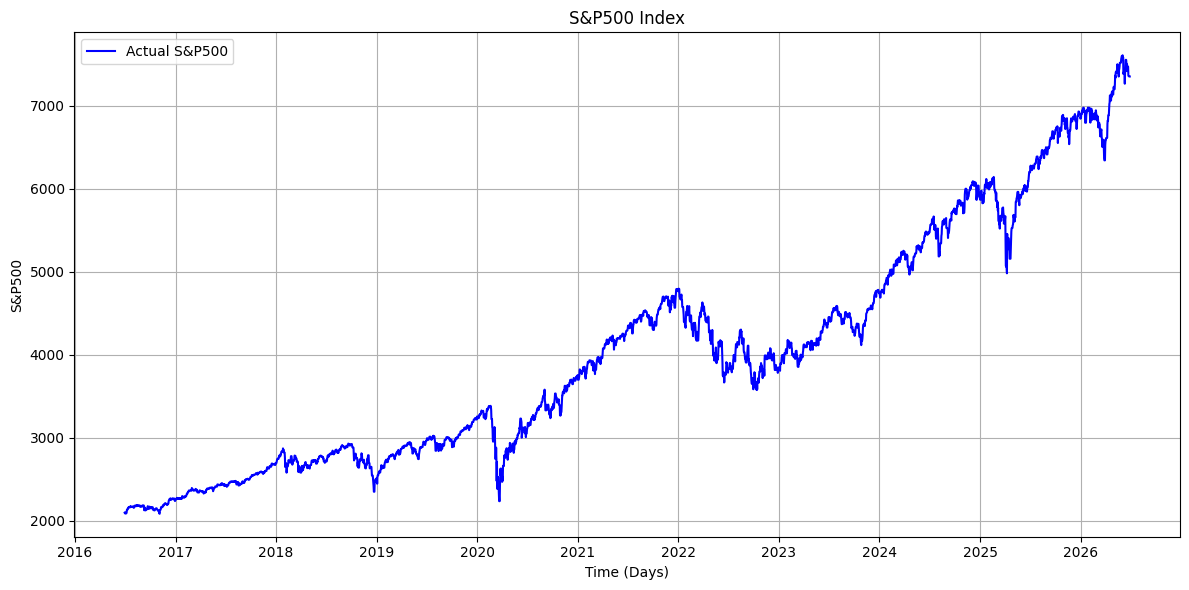

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(combined_df["SP500"], label='Actual S&P500', color='blue')
plt.title("S&P500 Index")
plt.xlabel("Time (Days)")
plt.ylabel("S&P500")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# 7. Save to a single CSV
output_filename = "fred_combined_2022-2023.csv"
combined_df = combined_df.loc["2022-01-01":"2023-01-31"]

# Save to CSV
combined_df.to_csv(output_filename, index_label="DATE")

print(f"Filtered data saved to '{output_filename}'.")

Filtered data saved to 'fred_combined_2022-2023.csv'.


In [16]:
# ------------------------------------------------------------
# FNN MODEL
# ------------------------------------------------------------
# • Expects a cleaned CSV named `fred_combined_2022-2023.csv` with a DATE column
#   and a numeric target column (default: SP500).
# • Trains an MLP/FNN with time‑series CV, prints RMSEs, and visualises
#   (i) Train‑vs‑Val metrics per epoch and (ii) Predictions vs Actual on the
#   test partition of each fold.
# ------------------------------------------------------------

!pip install optuna

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

pd.options.display.max_columns = None

# For performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00


In [17]:
# --------------------------
# 1. HYPER-PARAMETERS
# --------------------------

TARGET_COL = "SP500"         # change to your prediction target
TEST_SIZE = 0.10             # share of full sample set aside for test in each CV split
VAL_SIZE = 0.10              # share of training slice used for validation
N_SPLITS = 10                 # number of time‑series folds
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
HIDDEN_DIMS = [256, 128, 64]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
# --------------------------
# 2. LOAD & SCALE DATA
# --------------------------

CSV_PATH = Path("fred_combined_2022-2023.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"{CSV_PATH} not found. Place it next to this script.")

raw = (
    pd.read_csv(CSV_PATH, parse_dates=["DATE"]).sort_values("DATE")
)

X = raw.drop(columns=["DATE", TARGET_COL]).values.astype(np.float32)
y = raw[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

scaler_X, scaler_y = StandardScaler(), StandardScaler()

ts_cv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=int(TEST_SIZE * len(raw)))

cv_rmse, cv_mae, cv_mape = [], [], []

def build_model(in_dim: int, hidden_dims):
    layers, dims = [], [in_dim] + hidden_dims + [1]
    for d_in, d_out in zip(dims[:-2], dims[1:-1]):
        layers += [nn.Linear(d_in, d_out), nn.ReLU(), nn.LayerNorm(d_out), nn.Dropout(0.1)]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

In [19]:
# --------------------------
# 3. CROSS-VALIDATION LOOP
# --------------------------
for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X)):
    tr_limit = int((1 - VAL_SIZE) * len(train_idx))
    tr_idx, val_idx = train_idx[:tr_limit], train_idx[tr_limit:]

    X_train = scaler_X.fit_transform(X[tr_idx])
    y_train = scaler_y.fit_transform(y[tr_idx])
    X_val   = scaler_X.transform(X[val_idx])
    y_val   = scaler_y.transform(y[val_idx])
    X_test  = scaler_X.transform(X[test_idx])
    y_test  = scaler_y.transform(y[test_idx])

    # training
    ds_tr = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)

    model = build_model(X.shape[1], HIDDEN_DIMS).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    train_mse_hist, val_rmse_hist = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train(); epoch_loss = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); preds = model(xb)
            loss = criterion(preds, yb); loss.backward(); opt.step()
            epoch_loss += loss.item() * xb.size(0)
        train_mse = epoch_loss / len(dl_tr.dataset)
        train_mse_hist.append(train_mse)

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.from_numpy(X_val).to(DEVICE)).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        val_rmse_hist.append(val_rmse)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Fold {fold+1}/{N_SPLITS} | Epoch {epoch:02d}/{EPOCHS} | Train MSE {train_mse:.6f} | Val RMSE {val_rmse:.6f}")

Fold 1/10 | Epoch 01/50 | Train MSE 0.786641 | Val RMSE 0.874489
Fold 1/10 | Epoch 10/50 | Train MSE 0.050426 | Val RMSE 0.126399
Fold 1/10 | Epoch 20/50 | Train MSE 0.045861 | Val RMSE 0.224837
Fold 1/10 | Epoch 30/50 | Train MSE 0.107651 | Val RMSE 0.179014
Fold 1/10 | Epoch 40/50 | Train MSE 0.006128 | Val RMSE 0.023252
Fold 1/10 | Epoch 50/50 | Train MSE 0.017479 | Val RMSE 0.060045
Fold 2/10 | Epoch 01/50 | Train MSE 0.692427 | Val RMSE 0.714404
Fold 2/10 | Epoch 10/50 | Train MSE 0.083336 | Val RMSE 0.702056
Fold 2/10 | Epoch 20/50 | Train MSE 0.061146 | Val RMSE 0.577268
Fold 2/10 | Epoch 30/50 | Train MSE 0.083568 | Val RMSE 0.709536
Fold 2/10 | Epoch 40/50 | Train MSE 0.041442 | Val RMSE 0.552340
Fold 2/10 | Epoch 50/50 | Train MSE 0.042445 | Val RMSE 0.616857
Fold 3/10 | Epoch 01/50 | Train MSE 0.907655 | Val RMSE 1.698919
Fold 3/10 | Epoch 10/50 | Train MSE 0.123583 | Val RMSE 1.183008
Fold 3/10 | Epoch 20/50 | Train MSE 0.090065 | Val RMSE 0.996741
Fold 3/10 | Epoch 30/50 |

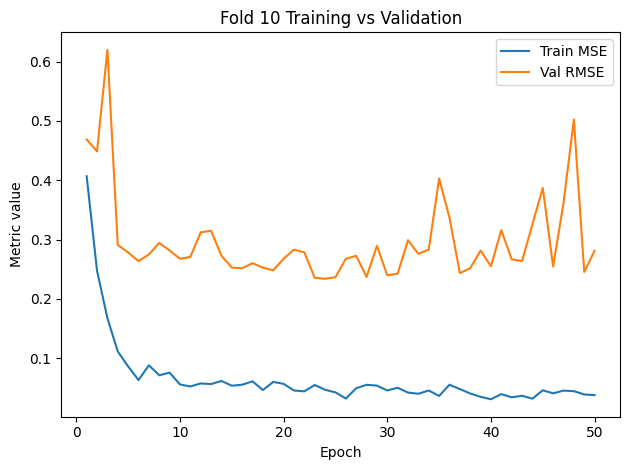

In [20]:
    # —— PLOT TRAINING CURVES ——
    plt.figure()
    plt.plot(range(1, EPOCHS + 1), train_mse_hist, label="Train MSE")
    plt.plot(range(1, EPOCHS + 1), val_rmse_hist, label="Val RMSE")
    plt.xlabel("Epoch"); plt.ylabel("Metric value")
    plt.title(f"Fold {fold+1} Training vs Validation")
    plt.legend(); plt.tight_layout(); plt.show()

Fold 10 Test RMSE: 0.324758



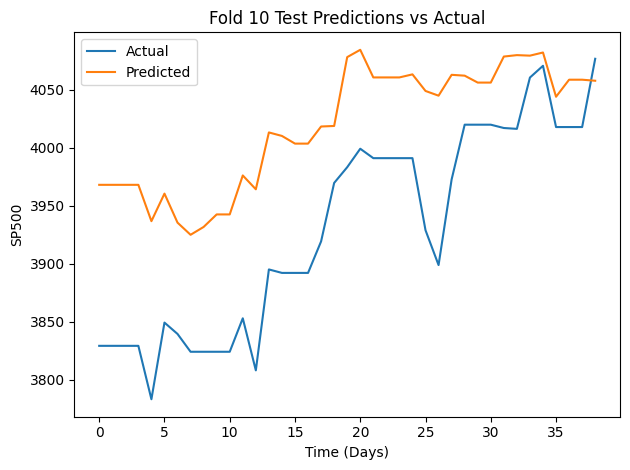

In [21]:
    # —— Evaluate on test ——
    with torch.no_grad():
        y_pred = model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy()
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_rmse.append(rmse_test)
    print(f"Fold {fold+1} Test RMSE: {rmse_test:.6f}\n")

    # —— Plot predictions vs actual ——
    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    plt.figure()
    plt.plot(y_test_inv.flatten(), label="Actual")
    plt.plot(y_pred_inv.flatten(), label="Predicted")
    plt.xlabel("Time (Days)"); plt.ylabel(TARGET_COL)
    plt.title(f"Fold {fold+1} Test Predictions vs Actual")
    plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# --------------------------
# 4. SUMMARY STATISTICS
# --------------------------
print("Per‑fold Test RMSE:", [f"{m:.4f}" for m in cv_rmse])
print("Per‑fold Test MAE :", [f"{m:.4f}" for m in cv_mae])
print("Per‑fold Test MAPE:", [f"{m:.2f}%" for m in cv_mape])
print(f"Mean Test RMSE : {np.mean(cv_rmse):.4f}")
print(f"Mean Test MAE  : {np.mean(cv_mae):.4f}")
print(f"Mean Test MAPE : {np.mean(cv_mape):.2f}%")

Per‑fold Test RMSE: ['0.3248']
Per‑fold Test MAE : []
Per‑fold Test MAPE: []
Mean Test RMSE : 0.3248
Mean Test MAE  : nan
Mean Test MAPE : nan%


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [28]:
import optuna

# --------------------------
# 5. HYPER-PARAMETER TUNING BAYESIAN OPTIMIZATION
# --------------------------
CSV_PATH = "fred_combined_2022-2023.csv"
TARGET_COL = "SP500"
VAL_SIZE = 0.10
TEST_SIZE = 0.10
N_SPLITS = 5
EPOCHS = 50
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [29]:
# Load data
raw = pd.read_csv(CSV_PATH, parse_dates=["DATE"]).sort_values("DATE")
X = raw.drop(columns=["DATE", TARGET_COL]).values.astype(np.float32)
y = raw[TARGET_COL].values.astype(np.float32).reshape(-1, 1)
ts_cv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=int(TEST_SIZE * len(raw)))

In [30]:
def build_model(in_dim, hidden_dims, dropout):
    dims = [in_dim] + hidden_dims + [1]
    layers = []
    for d_in, d_out in zip(dims[:-2], dims[1:-1]):
        layers += [
            nn.Linear(d_in, d_out),
            nn.ReLU(),
            nn.LayerNorm(d_out),  # ← use this instead of BatchNorm1d
            nn.Dropout(dropout)
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

In [31]:
# Objective function
def objective(trial):
    h1 = trial.suggest_int("h1", 64, 256)
    h2 = trial.suggest_int("h2", 32, 128)
    h3 = trial.suggest_int("h3", 16, 64)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    hidden_dims = [h1, h2, h3]

    scaler_X, scaler_y = StandardScaler(), StandardScaler()
    rmse_scores = []

    for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X)):
        tr_limit = int((1 - VAL_SIZE) * len(train_idx))
        tr_idx, val_idx = train_idx[:tr_limit], train_idx[tr_limit:]

        X_train = scaler_X.fit_transform(X[tr_idx])
        y_train = scaler_y.fit_transform(y[tr_idx])
        X_val = scaler_X.transform(X[val_idx])
        y_val = scaler_y.transform(y[val_idx])

        ds_tr = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)

        model = build_model(X.shape[1], hidden_dims, dropout).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        for epoch in range(EPOCHS):
            model.train()
            for xb, yb in dl_tr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.from_numpy(X_val).to(DEVICE)).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        rmse_scores.append(val_rmse)

    return np.mean(rmse_scores)

In [32]:
import optuna

# Run Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best RMSE:", study.best_value)
print("Best Parameters:", study.best_params)

[I 2026-06-28 14:03:42,751] A new study created in memory with name: no-name-07a7d648-dc46-458f-997c-a754155e3904
[I 2026-06-28 14:03:46,493] Trial 0 finished with value: 0.35932302118965537 and parameters: {'h1': 127, 'h2': 87, 'h3': 39, 'lr': 0.0021393892816326514, 'dropout': 0.2514212891761287}. Best is trial 0 with value: 0.35932302118965537.
[I 2026-06-28 14:03:49,967] Trial 1 finished with value: 0.3165066708726109 and parameters: {'h1': 82, 'h2': 77, 'h3': 27, 'lr': 0.0015976512009218036, 'dropout': 0.0982165556735442}. Best is trial 1 with value: 0.3165066708726109.
[I 2026-06-28 14:03:53,168] Trial 2 finished with value: 0.2998038089309464 and parameters: {'h1': 150, 'h2': 89, 'h3': 32, 'lr': 0.0013422161479705007, 'dropout': 0.10729138072920924}. Best is trial 2 with value: 0.2998038089309464.
[I 2026-06-28 14:03:56,581] Trial 3 finished with value: 0.3593730989905084 and parameters: {'h1': 143, 'h2': 119, 'h3': 47, 'lr': 0.006864167890715837, 'dropout': 0.11010088072695001}.

Best RMSE: 0.29377682145432754
Best Parameters: {'h1': 210, 'h2': 51, 'h3': 34, 'lr': 0.003668421995396301, 'dropout': 0.08358680904333779}


In [33]:
# --------------------------
# 6. OPTIMIZED FNN
# --------------------------
TARGET_COL = "SP500"
TEST_SIZE = 0.10
VAL_SIZE = 0.10
N_SPLITS = 10
BATCH_SIZE = 64
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Optimized Parameters
best_params = {
    'h1': 206,
    'h2': 126,
    'h3': 52,
    'lr': 0.005732306892937429,
    'dropout': 0.06939903355933769
}

In [34]:
HIDDEN_DIMS = [best_params['h1'], best_params['h2'], best_params['h3']]
LR = best_params['lr']

CSV_PATH = Path("fred_combined_2022-2023.csv")
raw = pd.read_csv(CSV_PATH, parse_dates=["DATE"]).sort_values("DATE")

X = raw.drop(columns=["DATE", TARGET_COL]).values.astype(np.float32)
y = raw[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

scaler_X, scaler_y = StandardScaler(), StandardScaler()
ts_cv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=int(TEST_SIZE * len(raw)))

cv_rmse, cv_mae, cv_mape = [], [], []

In [35]:
def build_model(in_dim: int, hidden_dims):
    layers, dims = [], [in_dim] + hidden_dims + [1]
    for d_in, d_out in zip(dims[:-2], dims[1:-1]):
        layers += [
            nn.Linear(d_in, d_out),
            nn.ReLU(),
            nn.LayerNorm(d_out),
            nn.Dropout(best_params['dropout'])
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

# --------------------------
# 3. Cross-Validation Loop
# --------------------------
for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X)):
    tr_limit = int((1 - VAL_SIZE) * len(train_idx))
    tr_idx, val_idx = train_idx[:tr_limit], train_idx[tr_limit:]

    X_train = scaler_X.fit_transform(X[tr_idx])
    y_train = scaler_y.fit_transform(y[tr_idx])
    X_val   = scaler_X.transform(X[val_idx])
    y_val   = scaler_y.transform(y[val_idx])
    X_test  = scaler_X.transform(X[test_idx])
    y_test  = scaler_y.transform(y[test_idx])

    ds_tr = torch.utils.data.TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)

    model = build_model(X.shape[1], HIDDEN_DIMS).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    train_mse_hist, val_rmse_hist = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train(); epoch_loss = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); preds = model(xb)
            loss = criterion(preds, yb); loss.backward(); opt.step()
            epoch_loss += loss.item() * xb.size(0)
        train_mse = epoch_loss / len(dl_tr.dataset)
        train_mse_hist.append(train_mse)

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.from_numpy(X_val).to(DEVICE)).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        val_rmse_hist.append(val_rmse)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Fold {fold+1}/{N_SPLITS} | Epoch {epoch:02d}/{EPOCHS} | Train MSE {train_mse:.6f} | Val RMSE {val_rmse:.6f}")

Fold 1/10 | Epoch 01/50 | Train MSE 1.576938 | Val RMSE 0.310974
Fold 1/10 | Epoch 10/50 | Train MSE 0.040159 | Val RMSE 0.078843
Fold 1/10 | Epoch 20/50 | Train MSE 0.025287 | Val RMSE 0.219746
Fold 1/10 | Epoch 30/50 | Train MSE 0.005545 | Val RMSE 0.116132
Fold 1/10 | Epoch 40/50 | Train MSE 0.031083 | Val RMSE 0.156512
Fold 1/10 | Epoch 50/50 | Train MSE 0.017293 | Val RMSE 0.027891
Fold 2/10 | Epoch 01/50 | Train MSE 1.744435 | Val RMSE 1.061505
Fold 2/10 | Epoch 10/50 | Train MSE 0.092967 | Val RMSE 0.527850
Fold 2/10 | Epoch 20/50 | Train MSE 0.066993 | Val RMSE 0.790074
Fold 2/10 | Epoch 30/50 | Train MSE 0.047301 | Val RMSE 0.638405
Fold 2/10 | Epoch 40/50 | Train MSE 0.063267 | Val RMSE 0.661802
Fold 2/10 | Epoch 50/50 | Train MSE 0.027243 | Val RMSE 0.670193
Fold 3/10 | Epoch 01/50 | Train MSE 2.086344 | Val RMSE 1.862446
Fold 3/10 | Epoch 10/50 | Train MSE 0.097842 | Val RMSE 1.270446
Fold 3/10 | Epoch 20/50 | Train MSE 0.067415 | Val RMSE 1.115643
Fold 3/10 | Epoch 30/50 |

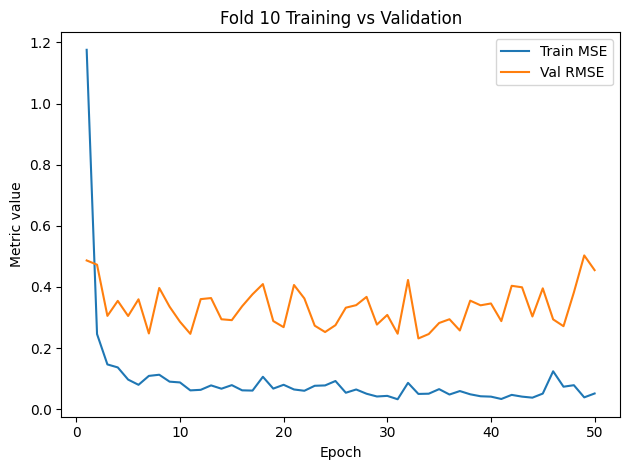

In [36]:
# Plot training curve
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_mse_hist, label="Train MSE")
plt.plot(range(1, EPOCHS + 1), val_rmse_hist, label="Val RMSE")
plt.xlabel("Epoch"); plt.ylabel("Metric value")
plt.title(f"Fold {fold+1} Training vs Validation")
plt.legend(); plt.tight_layout(); plt.show()

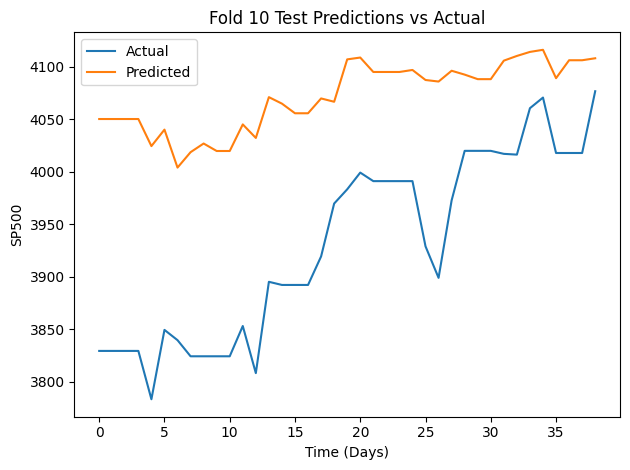

In [37]:
# Test evaluation
model.eval()
with torch.no_grad():
    y_pred = model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy()

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_test = mean_absolute_error(y_test, y_pred)
    mape_test = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    cv_rmse.append(rmse_test)
    cv_mae.append(mae_test)
    cv_mape.append(mape_test)

    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)

    plt.figure()
    plt.plot(y_test_inv.flatten(), label="Actual")
    plt.plot(y_pred_inv.flatten(), label="Predicted")
    plt.xlabel("Time (Days)")
    plt.ylabel(TARGET_COL)
    plt.title(f"Fold {fold+1} Test Predictions vs Actual")
    plt.legend(); plt.tight_layout(); plt.show()

In [38]:
# --------------------------
# 4. Final Summary
# --------------------------
print("------------- Summary -------------")
print("Per‑fold Test RMSE:", [f"{m:.4f}" for m in cv_rmse])
print("Per‑fold Test MAE :", [f"{m:.4f}" for m in cv_mae])
print("Per‑fold Test MAPE:", [f"{m:.2f}%" for m in cv_mape])
print(f"Mean Test RMSE : {np.mean(cv_rmse):.4f}")
print(f"Mean Test MAE  : {np.mean(cv_mae):.4f}")
print(f"Mean Test MAPE : {np.mean(cv_mape):.2f}%")

------------- Summary -------------
Per‑fold Test RMSE: ['0.5070']
Per‑fold Test MAE : ['0.4680']
Per‑fold Test MAPE: ['76.32%']
Mean Test RMSE : 0.5070
Mean Test MAE  : 0.4680
Mean Test MAPE : 76.32%
